In [1]:
import torch, torchvision
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from torchvision.models import MobileNet_V2_Weights
import matplotlib.pyplot as plt

# Data Loading, Transforming it

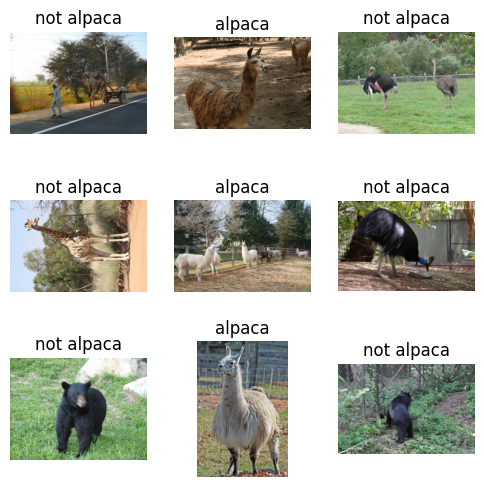

In [2]:
img_folder = ImageFolder(root="../../Datasets/alpaca-dataset")
classes = img_folder.classes

img, label = img_folder[0]
plt.figure(figsize=(6,6))
for i, idx in enumerate(torch.randint(0, len(img_folder), size=(9,))):
    plt.subplot(3,3, i+1)
    img, label = img_folder[idx]
    plt.imshow(img)
    plt.title(classes[label])
    plt.axis("off")
plt.show()

In [3]:
img, label = img_folder[idx]
print(type(img))
img = transforms.ToTensor()(img)
print(type(img), img.shape)

<class 'PIL.Image.Image'>
<class 'torch.Tensor'> torch.Size([3, 680, 1024])


img.mean()=tensor(0.4203), img.var()=tensor(0.0242), img.min()=tensor(0.0039), img.max()=tensor(1.), img.shape=torch.Size([3, 680, 1024])


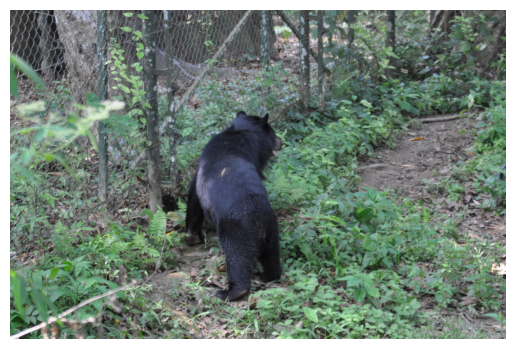

In [4]:
print(f"{img.mean()=}, {img.var()=}, {img.min()=}, {img.max()=}, {img.shape=}")
plt.imshow(img.permute(1,2,0))
plt.axis("off")
plt.show()

torch.Size([3, 160, 160])


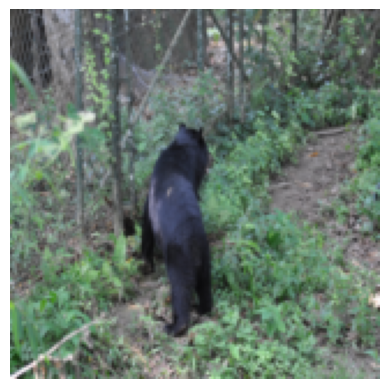

In [5]:
print(transforms.Resize(size=(160, 160))(img).shape)
plt.imshow(transforms.Resize(size=(160, 160))(img).permute(1,2,0))
plt.axis("off")
plt.show()


In [6]:
img_size=(160, 160)

In [7]:
transform_img = transforms.Compose([
    transforms.Resize(size=img_size),
    transforms.ToTensor()
])
img_folder = ImageFolder(root="../../Datasets/alpaca-dataset", transform=transform_img)
data_loader = DataLoader(dataset=img_folder, batch_size=32, shuffle=True)

In [8]:
total_data = len(img_folder)
total_data

327

In [9]:
classes = img_folder.classes
num_classes = len(classes)

In [10]:
train, test = random_split(img_folder, lengths=[0.8, 0.2])
train_len = len(train)
test_len = len(test)
print(len(train), len(test))

262 65


In [11]:
tx, ty = train.dataset[0]
tx.shape, classes[ty]

(torch.Size([3, 160, 160]), 'alpaca')

In [12]:
train_loader = DataLoader(dataset = train, batch_size=32, shuffle=True)

In [13]:
for batch_idx, (inputs, labels) in enumerate(train_loader):
    print(batch_idx)
    for input, label in zip(inputs, labels):
        # each input and it's corresponding label
        pass

0
1
2
3
4
5
6
7
8


# Download the model

In [14]:
mobilenet_classes = []
with open("../../Datasets/imagenet_classes.txt", "r") as f:
    mobilenet_classes = [s.strip() for s in f.readlines()]
    
print(len(mobilenet_classes), mobilenet_classes[:10])

1000 ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich']


In [77]:
model = torch.hub.load('pytorch/vision:v0.10.0', 'mobilenet_v2', pretrained=True)
params = sum([p.numel() for p in model.parameters()])
print(f"{params=}")
print(model)

params=3504872
MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): Batch

Using cache found in /Users/raghu-2264/.cache/torch/hub/pytorch_vision_v0.10.0
/Users/raghu-2264/Raghu/Personal Works/learnings/llm-finetuning-journey/.venv/lib/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/raghu-2264/Raghu/Personal Works/learnings/llm-finetuning-journey/.venv/lib/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [16]:
type(model)

torchvision.models.mobilenetv2.MobileNetV2

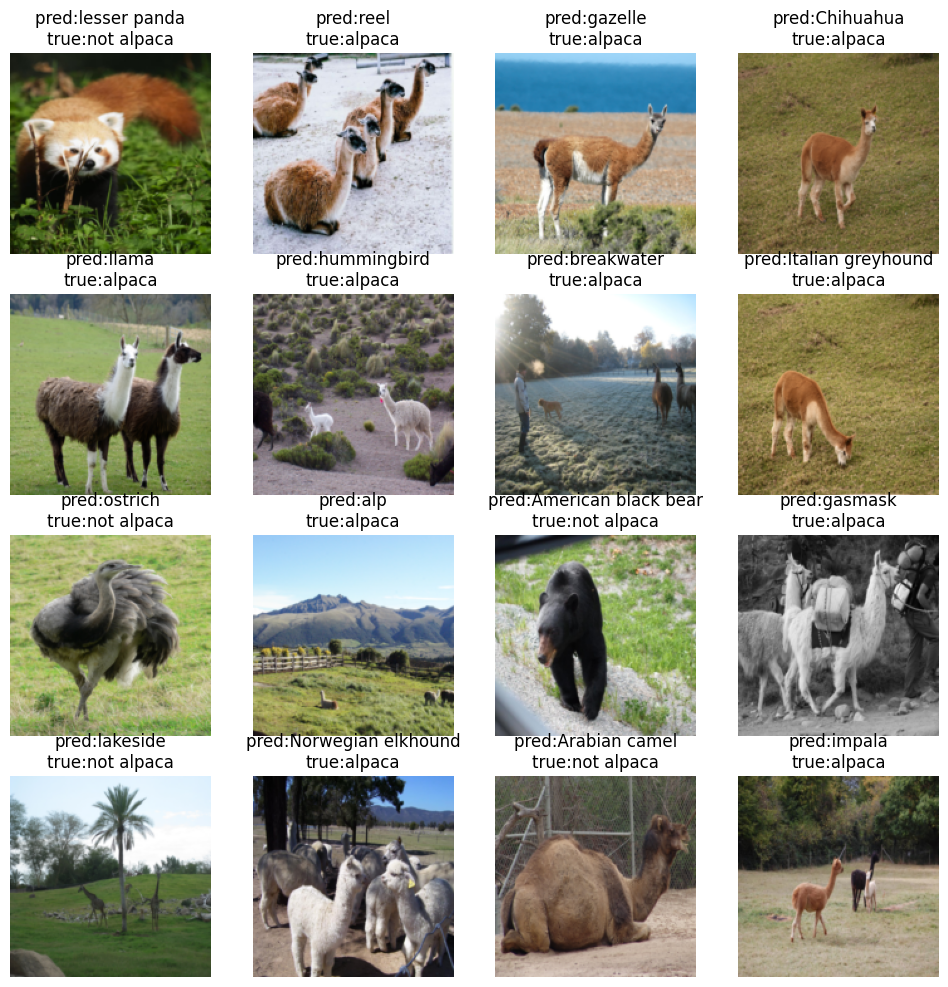

In [17]:
# Running the model in the local data
for batch_idx, (inputs, labels) in enumerate(train_loader):
    #print(batch_idx)
    ys = model(inputs)
    #print(ys.argmax(dim=1, keepdim=True))
    break

class_idx = ys.argmax(dim=1)
class_idx.shape, len(mobilenet_classes)
mobilenet_classes[class_idx[0]]

# some predictions
ti = 4
plt.figure(figsize=(12,12))
class_idx = ys.argmax(dim=1)
for i in range(ti**2):
    plt.subplot(ti, ti, i+1)
    plt.imshow(inputs[i].permute(1,2,0))
    plt.axis("off")
    plt.title(f"pred:{mobilenet_classes[class_idx[i]]}\ntrue:{classes[labels[i]]}")

# Create More Data now with augmentation

In [18]:
img_size = (224, 224)

In [19]:
img_folder = ImageFolder(root="../../Datasets/alpaca-dataset")
img, label = img_folder[0]
v2.ToTensor()(img).shape

/Users/raghu-2264/Raghu/Personal Works/learnings/llm-finetuning-journey/.venv/lib/python3.14/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


torch.Size([3, 670, 1024])

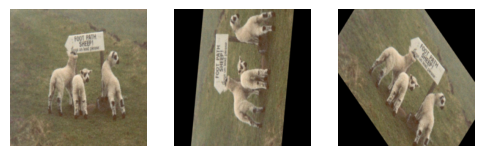

In [20]:
def get_random_images(img, img_size):
    channels, to_h, to_w = v2.ToTensor()(img).shape
    #v2.RandomCrop(size=img_size)(v2.Resize(size=(to_h//2, to_w//2))(img))
    #img1 = v2.RandomResizedCrop(size=img_size)(img) #random crop
    img2 = v2.Resize(size=img_size)(v2.RandomHorizontalFlip(p=0.5)(img)) #horizontal flip
    img3 = v2.Resize(size=img_size)(v2.RandomRotation(degrees=90, expand=False)(img)) #random rotate from -90 to +90 degree
    img4 = v2.Resize(size=img_size)(v2.RandomRotation(degrees=90, expand=False)(img)) #random rotate from -90 to +90 degree
    return [img2, img3, img4]

images = get_random_images(img, img_size)

plt.figure(figsize=(6,9))
for i in range(3):
    plt.subplot(1,3, i+1)
    plt.imshow(images[i])
    plt.axis('off')
plt.show()

In [21]:
pre_process = MobileNet_V2_Weights.IMAGENET1K_V2.transforms()
pre_transform, post_transform = transforms.ToTensor()(images[0]), pre_process(images[0])
print(f"Mean comparison: {pre_transform.mean(dim=(1,2))}, {post_transform.mean(dim=(1,2))}")
print(f"Variance comparison: {pre_transform.var(dim=(1,2))}, {post_transform.var(dim=(1,2))}")

Mean comparison: tensor([0.4966, 0.4612, 0.3556]), tensor([ 0.0545,  0.0266, -0.2226])
Variance comparison: tensor([0.0106, 0.0104, 0.0115]), tensor([0.2053, 0.2099, 0.2291])


In [362]:
for ch in layer.children():    
    print(ch.__class__.__name__)
    for n,p in ch.named_parameters():
        print("\t", n, len(p))
        pass

Conv2d
	 weight 1280
BatchNorm2d
	 weight 1280
	 bias 1280
ReLU6


In [ ]:
# freezing the weights of the model
for p in model.parameters():
    p.requires_grad = False

In [78]:
# freezing the weights of the model
n_layers_to_freeze = 18
for name, module in model.features.named_children():
    if int(name) <= n_layers_to_freeze:
        for p in module.parameters():
            p.requires_grad_(False)

In [ ]:
# freezing the weights of the model
n_layers_to_freeze = 18

for name, param in model.named_parameters():
    if name.startswith("features"):
        layer_number = int(name.split("features.")[1].split(".")[0])
        if layer_number <= n_layers_to_freeze:
            param.requires_grad = False

In [79]:
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

In [80]:
# change the model's classifier
new_classifier = nn.Sequential(
    nn.Linear(1280, 1)
)
model.classifier = new_classifier

In [81]:
for p in model.parameters():
    if p.requires_grad == True:
        print(p.shape)

torch.Size([1, 1280])
torch.Size([1])


# Layer Freezing: Writing full flow top to bottom

In [2]:
img_size = (224, 224)
transform_img = transforms.Compose([
    transforms.Resize(size=img_size),
    transforms.ToTensor()
])
img_folder = ImageFolder(root="../../Datasets/alpaca-dataset", transform=transform_img)

In [107]:
model = torch.hub.load('pytorch/vision:v0.10.0', 'mobilenet_v2', pretrained=True)
params = sum([p.numel() for p in model.parameters()])
print(f"{params=}")

params=3504872


Using cache found in /Users/raghu-2264/.cache/torch/hub/pytorch_vision_v0.10.0
/Users/raghu-2264/Raghu/Personal Works/learnings/llm-finetuning-journey/.venv/lib/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/raghu-2264/Raghu/Personal Works/learnings/llm-finetuning-journey/.venv/lib/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [108]:
pre_process = MobileNet_V2_Weights.IMAGENET1K_V2.transforms()
pre_transform, post_transform = img_folder[0][0], pre_process(img_folder[0][0])
print(f"Mean comparison: {pre_transform.mean(dim=(1,2))}, {post_transform.mean(dim=(1,2))}")
print(f"Variance comparison: {pre_transform.var(dim=(1,2))}, {post_transform.var(dim=(1,2))}")

Mean comparison: tensor([0.4966, 0.4612, 0.3556]), tensor([ 0.0542,  0.0263, -0.2229])
Variance comparison: tensor([0.0106, 0.0104, 0.0115]), tensor([0.2053, 0.2097, 0.2290])


In [109]:
def get_modified_model(model, n_layers_to_freeze=18):
    # for backup
    for p in model.parameters():
        p.requires_grad = True
    
    for name, param in model.named_parameters():
        if name.startswith("features"):
            layer_number = int(name.split("features.")[1].split(".")[0])
            if layer_number <= n_layers_to_freeze:
                param.requires_grad = False
                
    # change the model's classifier
    new_classifier = nn.Sequential(
        nn.Linear(1280, 1)
        #nn.Sigmoid() #comment to send the logits, without the activation layer
    )
    model.classifier = new_classifier
    
    return model

In [110]:
for p in get_modified_model(model).parameters():
    if p.requires_grad == True:
        print(p.shape)

torch.Size([1, 1280])
torch.Size([1])


In [111]:
def get_augmented_image(img, img_size):
    #channels, to_h, to_w = v2.ToTensor()(img).shape
    img2 = v2.Resize(size=img_size)(v2.RandomHorizontalFlip(p=0.5)(img)) #horizontal flip
    img3 = v2.Resize(size=img_size)(v2.RandomRotation(degrees=90, expand=False)(img)) #random rotate from -90 to +90 degree
    return img3


In [112]:
epochs = 5
data_loader = DataLoader(dataset=img_folder, batch_size=32, shuffle=True)
model_new = get_modified_model(model)
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)
losses = []

for epoch in range(epochs):
    
    for input, label in data_loader:
        
        input = pre_process(input)
        input = get_augmented_image(input, img_size=img_size)
        y_pred = model_new(input)
        
        #loss = F.binary_cross_entropy(y_pred, label.float().unsqueeze(dim=1))
        loss = F.binary_cross_entropy_with_logits(y_pred, label.float().unsqueeze(dim=1))
        losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        
        optimizer.step()
    
    print(sum(losses[-10:])/10)
    

0.6573915898799896
0.5529466360807419
0.5019297420978546
0.4981989085674286
0.43035063445568084


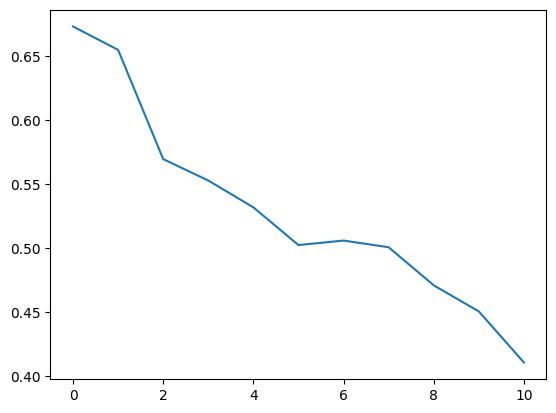

In [113]:
plt.plot(torch.tensor(losses).view(-1, 5).mean(1))
plt.show()

In [114]:
# Accuracy
diff_outputs = 0
model_new.eval()
with torch.no_grad():
    for input, label in data_loader:
        input = pre_process(input)
        y_pred = model_new(input)

        # if we used logits in model
        y_pred = ((y_pred > 0)*1).squeeze(dim=1) # 0 --> 0.5 of the sigmoid activation
        
        # if the sigmoid activation is used in the last layer of the model
        # y_pred = ((y_pred > 0)*1).squeeze(dim=1)
        #print(y_pred,'\n',label)
        diff_outputs += torch.abs(y_pred - label).sum()
        #print(diff_outputs)
        
    
print(f"{100*(1-diff_outputs/len(img_folder)):.4f}% accuracy on new model")

89.6024% accuracy on new model


# Fine-Tuning the deep layers

In [115]:
def get_modified_model_v2(model, n_layers_to_freeze=18):
    # for backup
    for p in model.parameters():
        p.requires_grad = True
    
    for name, param in model.named_parameters():
        if name.startswith("features"):
            layer_number = int(name.split("features.")[1].split(".")[0])
            if layer_number <= n_layers_to_freeze:
                param.requires_grad = False
    
    return model

In [116]:
epochs = 5
data_loader = DataLoader(dataset=img_folder, batch_size=32, shuffle=True)
model_new_2 = get_modified_model_v2(model_new, n_layers_to_freeze=12)
parameters = sum([p.numel() for p in model_new_2.parameters()])
print(f"Total parameters: {parameters}")

feature_extractor_params = []
classifier_params = []

for name, param in model_new_2.named_parameters():
    if param.requires_grad:
        if name.startswith("features"):
            feature_extractor_params.append(param)
        elif name.startswith("classifier"):
            classifier_params.append(param)

optimizer_groups = [
    {'params': feature_extractor_params, 'lr':1e-5},
    {'params': classifier_params, 'lr':1e-4}
]

optimizer = torch.optim.Adam(optimizer_groups) # using the prev optimizer, to continue learning
losses = []

for epoch in range(epochs):
    
    for input, label in data_loader:
        
        input = pre_process(input)
        input = get_augmented_image(input, img_size=img_size)
        y_pred = model_new_2(input)
        
        #loss = F.binary_cross_entropy(y_pred, label.float().unsqueeze(dim=1))
        loss = F.binary_cross_entropy_with_logits(y_pred, label.float().unsqueeze(dim=1))
        losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        
        optimizer.step()
    
    print(sum(losses[-10:])/10)
    

Total parameters: 2225153
0.4232668697834015
0.36340329200029375
0.3372941017150879
0.291299407184124
0.2864445447921753


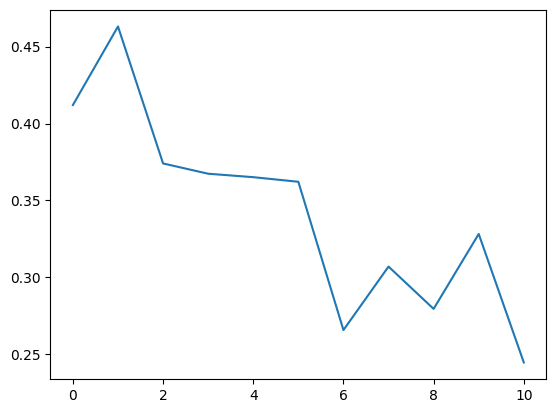

In [117]:
plt.plot(torch.tensor(losses).view(-1, 5).mean(1))
plt.show()

In [118]:
# Accuracy
diff_outputs = 0
model_new_2.eval()
with torch.no_grad():
    for input, label in data_loader:
        input = pre_process(input)
        y_pred = model_new_2(input)

        # if we used logits in model
        y_pred = ((y_pred > 0)*1).squeeze(dim=1) # 0 --> 0.5 of the sigmoid activation
        
        # if the sigmoid activation is used in the last layer of the model
        # y_pred = ((y_pred > 0)*1).squeeze(dim=1)
        #print(y_pred,'\n',label)
        diff_outputs += torch.abs(y_pred - label).sum()
        #print(diff_outputs)
        
    
print(f"{100*(1-diff_outputs/len(img_folder)):.4f}% accuracy on new model")

92.6606% accuracy on new model
